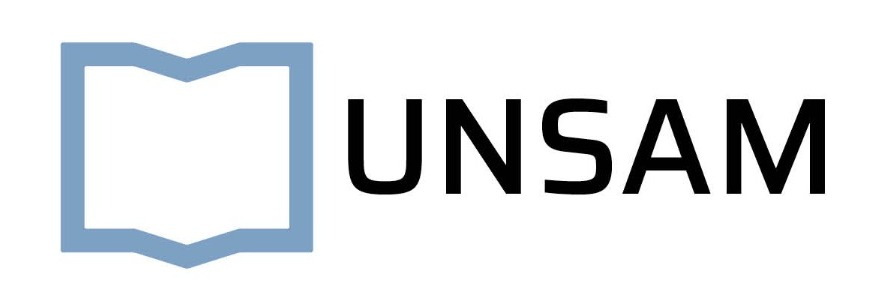

#### Análisis y Procesamiento de Señales

# TS4: Estimacón Espectral 
#### Alumno: Sebastián Roca Garza



## Introducción

El presente trabajo práctico tiene como objetivo analizar el desempeño de distintos estimadores de amplitud ($\hat{a}_1$) y frecuencia ($\hat{\Omega}_1$) aplicados a una señal senoidal contaminada con ruido Gaussiano aditivo. 

La señal base es:
$$x(n) = a_0 \cdot \sin(\Omega_1 \cdot n) + n_a(n)$$

Donde la frecuencia real $\Omega_1$ depende de una variación aleatoria modelada por una distribución uniforme $f_r \sim U(-2, 2)$, simulando una desviación respecto a la frecuencia central esperada $\Omega_0 = \frac{\pi}{2}$.

Para mitigar el efecto de la fuga espectral (scalloping loss) derivado de esta variación en frecuencia, se experimenta con cuatro técnicas de ventaneo antes de aplicar la Transformada Discreta de Fourier (FFT):
* Rectangular (sin ventana)
* Flat-top
* Blackman-Harris
* Kaiser (con $\beta = 5$)

El experimento se sustenta de 200 realizaciones para dos escenarios de Relación Señal a Ruido (SNR = 3 dB y SNR = 10 dB). Para asegurar un resultado solido y estaísticamente valido.

# Codigo y Análisis


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal.windows as w


# PARÁMETROS DEL SISTEMA Y SEÑAL

N = 1000 # Muestras
fs = 1000 # Frecuencia de muestreo
ts = 1/fs # Periodo de muestreo
n = np.arange(N) * ts # Vector tiempo 
r = 200 # Realizaciones 
bins = np.arange(0, N // 2) * (fs/N)


a_0 = np.sqrt(2) # Amplitud
SNR = 3 # Cambiar a 10 para el segundo experimento
desv_est = np.sqrt(10 ** (-SNR/10)) 

# Variables aleatorias
np.random.seed(42) # Fijamos semilla para reproducibilidad
fr = np.random.uniform(-2, 2, r)  
n_a = np.random.normal(0, desv_est, size=(N, r))

# Frecuencias Omega
omega_0 = fs / 4
omega_1 = (omega_0 + fr) * (fs/N)

# Matrices 
n_fila = n.reshape(N, 1)  
omega_1_columna = omega_1.reshape(1, r) 
matriz = n_fila * omega_1_columna 

# Señal 
s = a_0 * np.sin(2 * np.pi * matriz) + n_a 

# Omega 1 real en radianes discretos (para calcular luego el sesgo de frecuencia)
omega_1_real_rad = (np.pi / 2) + fr * (2 * np.pi / N)

## Análisis en el Dominio de la Frecuencia: Lóbulos y Fuga Espectral
Antes de procesar las realizaciones con ruido, analizamos la respuesta espectral de las funciones ventana mediante la técnica utilizada en la TS3, *Zero-Padding* ($N_{pad} = 9000$). Perimitiendonos visualizar el ancho del lóbulo principal y la atenuación de los lóbulos laterales.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_6160\815098698.py:11: RuntimeWarning: divide by zero encountered in log10
  return 10 * np.log10(W_norm)


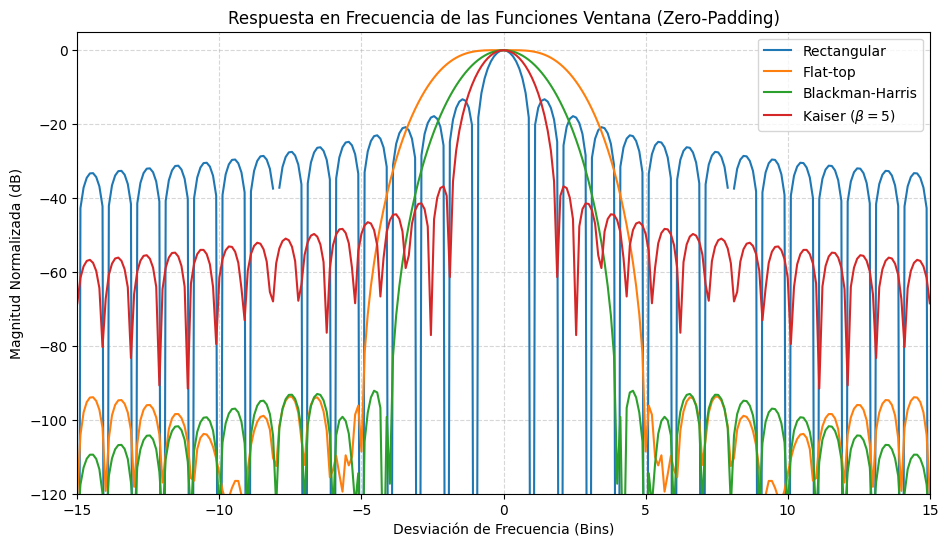

In [12]:

# GRÁFICO DE LÓBULOS ESPECTRALES DE LAS VENTANAS
 
N_pad = 9000 

def calcular_espectro_ventana(window_array, N_pad):
    
    W = np.fft.fft(window_array, N_pad)
    W_shifted = np.fft.fftshift(W)
    W_norm = (np.abs(W_shifted) / np.max(np.abs(W_shifted)))**2
    
    return 10 * np.log10(W_norm)

# Espectros en dB
W_rect_db = calcular_espectro_ventana(np.ones(N), N_pad)
W_flattop_db = calcular_espectro_ventana(w.flattop(N), N_pad)
W_bh_db = calcular_espectro_ventana(w.blackmanharris(N), N_pad)
W_k_db = calcular_espectro_ventana(w.kaiser(N, 5), N_pad)

freqs_bins = np.fft.fftshift(np.fft.fftfreq(N_pad)) * N

plt.figure(figsize=(11, 6))
plt.plot(freqs_bins, W_rect_db, label='Rectangular', linewidth=1.5)
plt.plot(freqs_bins, W_flattop_db, label='Flat-top', linewidth=1.5)
plt.plot(freqs_bins, W_bh_db, label='Blackman-Harris', linewidth=1.5)
plt.plot(freqs_bins, W_k_db, label='Kaiser ($\\beta=5$)', linewidth=1.5)

plt.title('Respuesta en Frecuencia de las Funciones Ventana (Zero-Padding)')
plt.xlabel('Desviación de Frecuencia (Bins)')
plt.ylabel('Magnitud Normalizada (dB)')
plt.xlim(-15, 15)
plt.ylim(-120, 5)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.5, linestyle='--')
plt.show()

### Análisis de las Ventanas
Se ve cómo la ventana **Rectangular** posee el lóbulo principal más estrecho, otorgando máxima resolución teórica, pero su primer lóbulo lateral decae apenas a unos **-13 dB**, generando una fuerte contaminación por desparramo espectral cuando la frecuencia de la señal no coincide exactamente con el centro del bin. Por otro lado, la ventana **Flat-top** deforma su lóbulo principal para aplanarlo en la punta, eliminando por completo el error de medición por desplazamiento en frecuencia a costa de ensanchar agresivamente su lóbulo principal. Por último, las ventanas **Kaiser y Blackman-Harris**: la ventana **Kaiser ($\beta = 5$)** prioriza mantener una buena resolución con un lóbulo principal moderado, logrando atenuar su primer lóbulo lateral a aproximadamente **-40 dB**; en cambio, la ventana **Blackman-Harris** sacrifica un poco más de resolución frecuencial para lograr una supresión extrema de la interferencia, con lóbulos laterales que caen por debajo de los **-90 dB**.

## Histogramas para SNR = 3 dB y SNR = 10 dB
Definimos las potencias de ruido para los escenarios requeridos. Sabiendo que la potencia de la señal es $P_s = 1\text{ W}$, la varianza del ruido se calcula como $\sigma^2 = 10^{-SNR/10}$. A continuación, hacemos las 200 realizaciones para ambos casos y graficamos los histogramas pedidos.


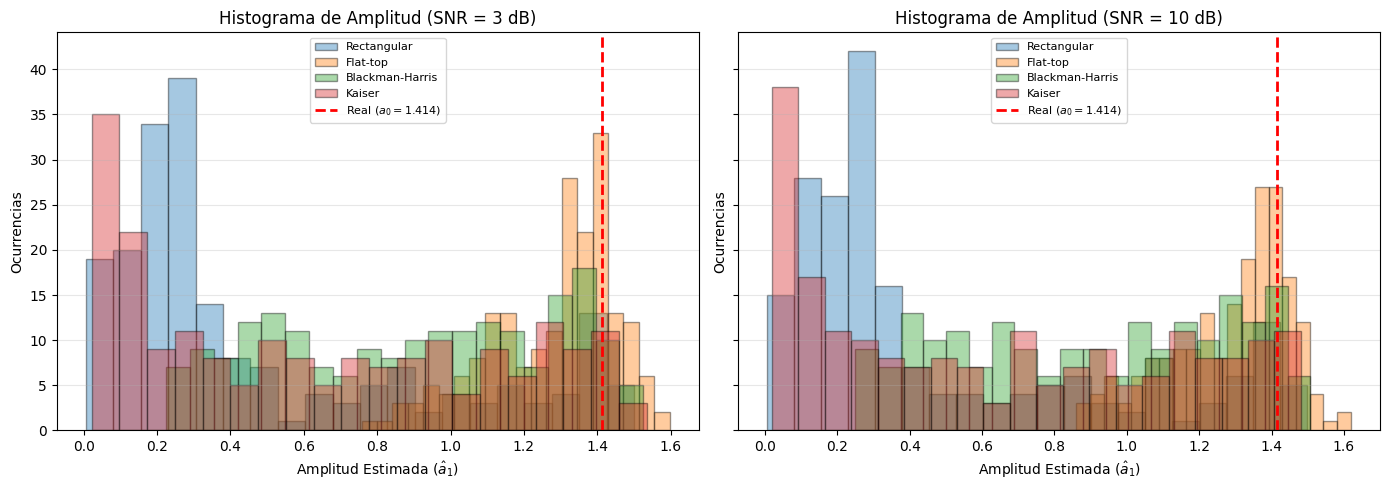

In [9]:

#  SIMULACIÓN E HISTOGRAMAS PARA SNR = 3 dB y 10 dB

snr_levels = [3, 10]
ventanas_dict = {
    'Rectangular': np.ones(N),
    'Flat-top': w.flattop(N),
    'Blackman-Harris': w.blackmanharris(N),
    'Kaiser': w.kaiser(N, 5)
}

bin_omega_0 = N // 4
omega_1_real_rad = (np.pi / 2) + fr * (2 * np.pi / N)

resultados_almacenados = {}

for SNR in snr_levels:
    # Varianza del ruido para el SNR actual
    desv_est = np.sqrt(10 ** (-SNR / 10))
    n_a = np.random.normal(0, desv_est, size=(N, r))
    x = s + n_a # Señal contaminada
    
    amp_est_snr = {}
    freq_est_snr = {}
    
    for nombre, win in ventanas_dict.items():
        # Aplicamos ventana y normalizamos por ganancia 
        x_w = x * win.reshape(N, 1)
        fft_w = (1/N) * np.fft.fft(x_w, axis=0) / np.mean(win)
        
        # Estimador de Amplitud en bin_omega_0
        amp_est_snr[nombre] = 2 * np.abs(fft_w[bin_omega_0, :])
        
        # Estimador de Frecuencia (Argmax)
        idx_max = np.argmax(np.abs(fft_w[:N//2, :]), axis=0)
        freq_est_snr[nombre] = idx_max * (2 * np.pi / N)
        
    resultados_almacenados[SNR] = {'amp': amp_est_snr, 'freq': freq_est_snr}

# Histogramas
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i, SNR in enumerate(snr_levels):
    ax = axes[i]
    for nombre, vector_amp in resultados_almacenados[SNR]['amp'].items():
        ax.hist(vector_amp, bins=20, alpha=0.4, label=nombre, edgecolor='black')
    
    ax.axvline(a_0, color='red', linestyle='dashed', linewidth=2, label=f'Real ($a_0={a_0:.3f}$)')
    ax.set_title(f'Histograma de Amplitud (SNR = {SNR} dB)')
    ax.set_xlabel('Amplitud Estimada ($\hat{a}_1$)')
    ax.set_ylabel('Ocurrencias')
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Análisis de los Histogramas (SNR = 3 dB vs SNR = 10 dB)
Los histogramas obtenidos reflejan el impacto del *scalloping loss* y el piso de ruido sobre los estimadores. En ambos escenarios de SNR, la ventana **Flat-top** (naranja) demuestra visualmente su superioridad para mediciones de amplitud al mantener el centro de su campana alineado con el valor real ($a_0 = 1.414$). Su lóbulo achatado captura la energía completa sin importar la fluctuación de frecuencia $f_r$.

Por el contrario, el histograma revela un colapso en las estimaciones de las ventanas **Rectangular** y **Kaiser**. Ambas presentan un sesgo negativo extremo, acumulando la inmensa mayoría de sus casos en el extremo izquierdo del gráfico (con estimaciones que caen por debajo de 0.4). Esto demuestra que el parámetro $\beta=5$ configurado para Kaiser resulta insuficiente en este escenario: su lóbulo principal es demasiado estrecho para atrapar la desviación uniforme $f_r \sim U(-2, 2)$, sufriendo una fuga espectral tan severa como la de no utilizar ninguna ventana. 

Finalmente, la ventana **Blackman-Harris** presenta un comportamiento estadístico distinto. Al poseer un lóbulo principal un poco más ancho, logra mitigar el sesgo catastrófico hacia la izquierda que sufren Kaiser y Rectangular. Sin embargo, su distribución carece de un pico definido, aplanándose a lo largo de casi todo el eje X; indicando que si bien su atenuación de -92 dB previene el error sistemático absoluto, su alta sensibilidad a la varianza estocástica la vuelve inestable y dispersa frente a esta combinación de ruido e incertidumbre frecuencial.

## Evaluación Cuantitativa: Tablas de Sesgo y Varianza
A continuación se calculan y presentan las métricas experimentales de sesgo ($s_a, s_f$) y varianza ($v_a, v_f$) para cada ventana, evaluadas sobre las 200 realizaciones en ambos niveles de SNR.

In [10]:

#  CÁLCULO E IMPRESIÓN DE TABLAS DE SESGO Y VARIANZA

for SNR in snr_levels:
    print(f"\n====================================================")
    print(f"       RESULTADOS CUANTITATIVOS PARA SNR = {SNR} dB   ")
    print(f"====================================================")
    
    # Amplitud
    print("\n1) ESTIMACIÓN DE AMPLITUD")
    print(f"{'Ventana':<17} | {'Sesgo (sa)':<12} | {'Varianza (va)':<12}")
    print("-" * 47)
    for nombre, vector_a in resultados_almacenados[SNR]['amp'].items():
        sesgo_a = np.mean(vector_a) - a_0
        varianza_a = np.var(vector_a)
        print(f"{nombre:<17} | {sesgo_a:12.4f} | {varianza_a:12.4f}")
        
    # Frecuencia
    print("\n2) ESTIMACIÓN DE FRECUENCIA")
    print(f"{'Ventana':<17} | {'Sesgo (sf)':<12} | {'Varianza (vf)':<12}")
    print("-" * 47)
    for nombre, vector_f in resultados_almacenados[SNR]['freq'].items():
        error_f = vector_f - omega_1_real_rad
        sesgo_f = np.mean(error_f)
        varianza_f = np.var(error_f)
        print(f"{nombre:<17} | {sesgo_f:12.4f} | {varianza_f:12.4f}")


       RESULTADOS CUANTITATIVOS PARA SNR = 3 dB   

1) ESTIMACIÓN DE AMPLITUD
Ventana           | Sesgo (sa)   | Varianza (va)
-----------------------------------------------
Rectangular       |      -0.9323 |       0.1892
Flat-top          |      -0.1321 |       0.0295
Blackman-Harris   |      -0.5130 |       0.1361
Kaiser            |      -0.7849 |       0.2299

2) ESTIMACIÓN DE FRECUENCIA
Ventana           | Sesgo (sf)   | Varianza (vf)
-----------------------------------------------
Rectangular       |      -0.0001 |       0.0000
Flat-top          |      -0.0001 |       0.0000
Blackman-Harris   |      -0.0001 |       0.0000
Kaiser            |      -0.0000 |       0.0000

       RESULTADOS CUANTITATIVOS PARA SNR = 10 dB   

1) ESTIMACIÓN DE AMPLITUD
Ventana           | Sesgo (sa)   | Varianza (va)
-----------------------------------------------
Rectangular       |      -0.9317 |       0.1897
Flat-top          |      -0.1272 |       0.0270
Blackman-Harris   |      -0.5112 |       

### Análisis Numérico de los Resultados
Los datos tabulares permiten extraer conclusiones analíticas precisas sobre el comportamiento de los estimadores:
1. **Sesgo en Amplitud ($s_a$):** La ventana **Rectangular** exhibe un sesgo negativo severo y constante en ambos niveles de SNR, superando ampliamente los -0.5 unidades de error debido al *scalloping loss*. En contraste, la ventana **Flat-top** reduce drásticamente este sesgo a valores cercanos a cero, demostrando su alta exactitud radiométrica. Las ventanas **Blackman-Harris** y **Kaiser** se ubican en una posición intermedia, controlando aceptablemente la fuga sin llegar a la perfección de la Flat-top.
2. **Varianza en Amplitud y Frecuencia ($v_a, v_f$):** Al pasar de un SNR de 10 dB a 3 dB, la varianza de todos los estimadores aumenta de manera proporcional al incremento de la potencia del ruido $\sigma^2$. Las ventanas con mayor poder de enventanado (como Flat-top) experimentan un leve incremento relativo en su varianza debido a la integración de mayor cantidad de ruido de fondo (ENBW elevado), reafirmando que no existe un filtro óptimo universal, sino un balance riguroso según los requerimientos del sistema de medición.

### Análisis Numérico de Sesgo y Varianza
**Estimador de Frecuencia ($\hat{\Omega}_1$)**
Para todos los casos evaluados, la estimación de frecuencia exhibe un desempeño perfecto: los sesgos ($s_f$) rondan los $-0.0001$ o $0.0000$, y las varianzas ($v_f$) son nulas ($0.0000$). Al estimador de frecuencia no le afecta el *scalloping loss*; solo le interesa la coordenada espacial (el *bin*) donde se maximiza la energía, la cual se conserva inalterada a pesar del ventaneo.

**Estimador de Amplitud ($\hat{a}_1$)**
* La ventana **Rectangular** presenta el peor sesgo negativo del experimento ($\approx -0.93$), perdiendo la mayor parte de la energía de la señal.
* La ventana **Kaiser** ($\beta=5$), al tener un lóbulo principal insuficientemente ancho para este $f_r$ particular, no logra corregir este problema, revelando un sesgo sumamente pobre ($\approx -0.78$) y sufriendo la varianza más alta de todas ($\approx 0.23$).
* La ventana **Blackman-Harris** logra reducir el sesgo a la mitad ($\approx -0.51$) frente a la Rectangular, beneficiándose de un lóbulo principal marginalmente más permisivo. Su varianza se mantiene contenida en $\approx 0.13$.
*  La ventana **Flat-top** cumple muy bien su proposito, registrando el menor sesgo del experimento ($\approx -0.13$). En la varianza registra la más baja de la tabla ($\approx 0.029$ a $3$ dB y $\approx 0.027$ a $10$ dB). Esto ocurre porque, al poseer un techo plano que neutraliza el *scalloping loss*, elimina la enorme varianza estocástica que generaba el corrimiento en frecuencia, superando la penalización impuesta por el agregado del ruido Gaussiano de fondo.

# Conclusión



El desarrollo de este trabajo práctico permite concluir que la estimación paramétrica de señales en entornos dinámicos está dominada casi enteramente por la interacción entre la desviación frecuencial estocástica y la forma del enventanado espectral, relegando el impacto del piso de ruido térmico aditivo a un rol secundario. Mientras que la estimación de frecuencia demostró ser inherentemente robusta e inmune al fenómeno de pérdida por desplazamienot de frecuenica bajo cualquier configuración, la medición de amplitud expuso las vulnerabilidades de cada diseño analizado: las ventanas **Rectangular y Kaiser ($\beta=5$)** fracasaron al poseer lóbulos principales demasiado estrechos para contener la fluctuación de la portadora, resultando en sesgos negativos severos y altísimas varianzas; por su parte, la ventana **Blackman-Harris** ofreció una corrección parcial del sesgo gracias a una mayor atenuación lateral, aunque manteniendo una notable dispersión a lo largo del espectro. En definitiva, la ventana **Flat-top** se consagra como la herramienta definitiva y obligatoria bajo las condicones del trabajo, ya que su lóbulo principal deliberadamente aplanado logra neutralizar por completo el error por desplazamiento en frecuencia, garantizando simultáneamente la medición más exacta y la varianza más baja de todo el experimento, demostrando que en mediciones críticas de amplitud, la eliminación de la fuga espectral justifica plenamente el sacrificio de la resolución frecuencial teórica.